# Entendimiento de datos

**Conjunto de datos:** Dataset 4 - Matriz Variable - Tipo de combustible

**Nombre de archivo:** variable_fuel_matrix.csv

## 0. Inicialización

### 0.1. Perfilamiento de datos

Instalar ydata-profiling

In [1]:
!pip install ydata-profiling

Importaciones

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns

import re
from tabulate import tabulate

Visualización de tablas y gráficas

In [3]:
sns.set_style("darkgrid")

def print_table(df):
    print(tabulate(df, headers='keys', tablefmt='simple_outline'))

Lectura y muestra del archivo

In [4]:
df = pd.read_csv("../data/enriquecida/variable_fuel_matrix.csv")
df.head()

,Variable,Tipo de combustible,Probabilidad,Justificación,Ponderación
0,SO2,Sin definir,2,Probabilidad baja — podría ser cualquier cosa;...,0.6
1,SO2,Carbón,6,"Moderada — carbón suele contener azufre, gener...",0.6
2,SO2,Otros,3,Baja a moderada — depende del tipo; mantengo c...,0.6
3,SO2,Gas,1,Baja — gas natural típicamente tiene poco azufre.,0.6
4,SO2,ACPM,9,"Alta — El SO2 se forma con la quema de diésel,...",0.6


Información del archivo (Cantidad de filas, cantidad de columnas y tipos de dato)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Variable             96 non-null     object 
 1   Tipo de combustible  96 non-null     object 
 2   Probabilidad         96 non-null     int64  
 3   Justificación        96 non-null     object 
 4   Ponderación          96 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 3.9+ KB


Columnas agrupadas por tipo de dato

In [6]:
columnas_por_tipo = df.columns.to_series().groupby(df.dtypes).groups

print("Columnas agrupadas por tipo de dato:\n")
for tipo, cols in columnas_por_tipo.items():
    print(f"{tipo} ({len(cols)} columnas): {', '.join(cols)}")

Columnas agrupadas por tipo de dato:

int64 (1 columnas): Probabilidad
float64 (1 columnas): Ponderación
object (3 columnas): Variable, Tipo de combustible, Justificación


## 1. Variables categóricas

Variables categóricas encontradas

In [7]:
non_numeric_attributes = ["Variable", "Tipo de combustible"]
pd.DataFrame(non_numeric_attributes, columns=['Non Numeric Attributes'])

,Non Numeric Attributes
0,Variable
1,Tipo de combustible


Conteos y porcentajes para cada valor único en las columnas. 

In [8]:
for col in non_numeric_attributes:
    attribute = df[col].value_counts()
    df_attribute = pd.DataFrame({
        f"{col} values": attribute.index,
        'Count': attribute.values,
        'Percentage (%)': attribute.values * 100 / attribute.values.sum()
    }).sort_values(by='Count', ascending=False)

    print_table(df_attribute)

┌────┬───────────────────┬─────────┬──────────────────┐
│    │ Variable values   │   Count │   Percentage (%) │
├────┼───────────────────┼─────────┼──────────────────┤
│  0 │ SO2               │      12 │             12.5 │
│  1 │ PM2.5             │      12 │             12.5 │
│  2 │ NO2               │      12 │             12.5 │
│  3 │ CO                │      12 │             12.5 │
│  4 │ NO                │      12 │             12.5 │
│  5 │ PM10              │      12 │             12.5 │
│  6 │ NOX               │      12 │             12.5 │
│  7 │ WDS               │      12 │             12.5 │
└────┴───────────────────┴─────────┴──────────────────┘
┌────┬──────────────────────────────┬─────────┬──────────────────┐
│    │ Tipo de combustible values   │   Count │   Percentage (%) │
├────┼──────────────────────────────┼─────────┼──────────────────┤
│  0 │ Sin definir                  │       8 │          8.33333 │
│  1 │ Carbón                       │       8 │          8.3

**Hallazgos:**

- Hay 15 variables y 12 tipos de combustible, tal como la cantidad de datos útiles en los otros datasets

## 2. Variables numéricas

Variables numéricas encontradas

In [9]:
numeric_attributes = df.select_dtypes(include=['number']).columns.values
pd.DataFrame(numeric_attributes, columns=['Numeric Attributes'])

,Numeric Attributes
0,Probabilidad
1,Ponderación


Conteo de filas, promedio, desviación estándar, valores mínimo y máximo junto a los cuartiles

In [10]:
df[numeric_attributes].describe()

,Probabilidad,Ponderación
count,96.000000,96.000000
mean,4.656250,0.537500
std,2.566292,0.086146
min,0.000000,0.400000
25%,2.000000,0.475000
50%,5.500000,0.600000
75%,6.250000,0.600000
max,9.000000,0.600000


Visualización de esta información con diagramas de caja

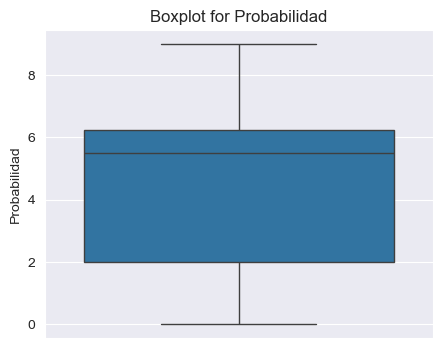

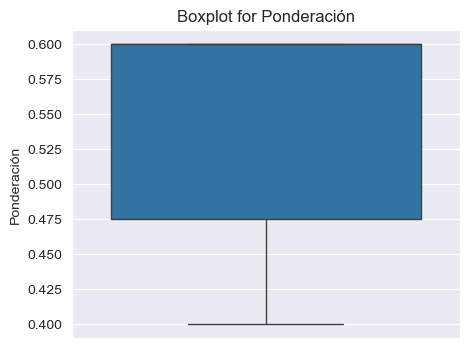

In [11]:
for col in numeric_attributes:
    plt.figure(figsize=(5,4))
    ax = sns.boxplot(data=df[col])
    ax.set_title(f"Boxplot for {col}")
    plt.xticks(rotation=45)
    plt.show()

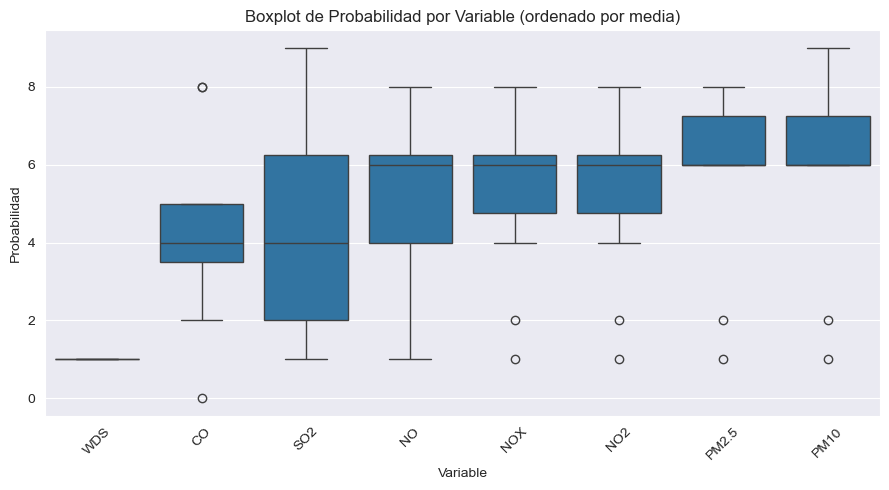

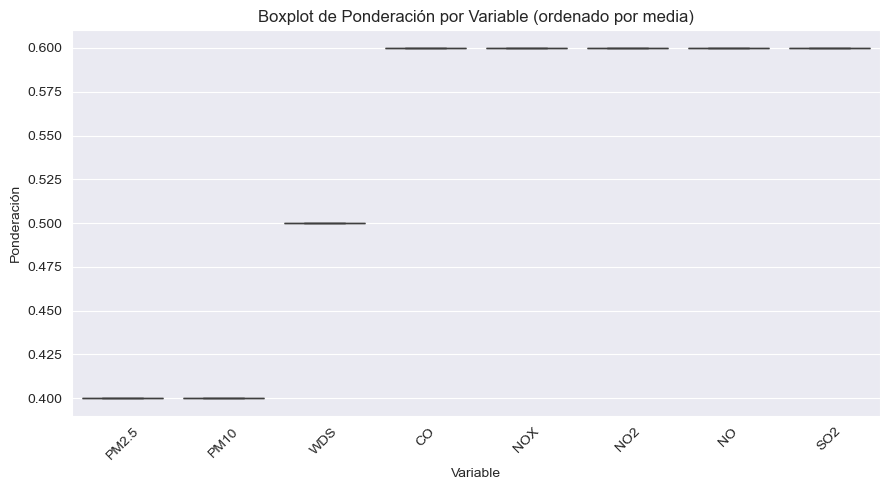

In [12]:
for col in numeric_attributes:
    # Calcular el orden de las categorías por la media de cada Variable
    order = (
        df.groupby("Variable")[col]
        .mean()
        .sort_values(ascending=True)  # o ascending=True si quieres de menor a mayor
        .index
    )

    plt.figure(figsize=(9, 5))
    ax = sns.boxplot(data=df, x="Variable", y=col, order=order)
    ax.set_title(f"Boxplot de {col} por Variable (ordenado por media)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

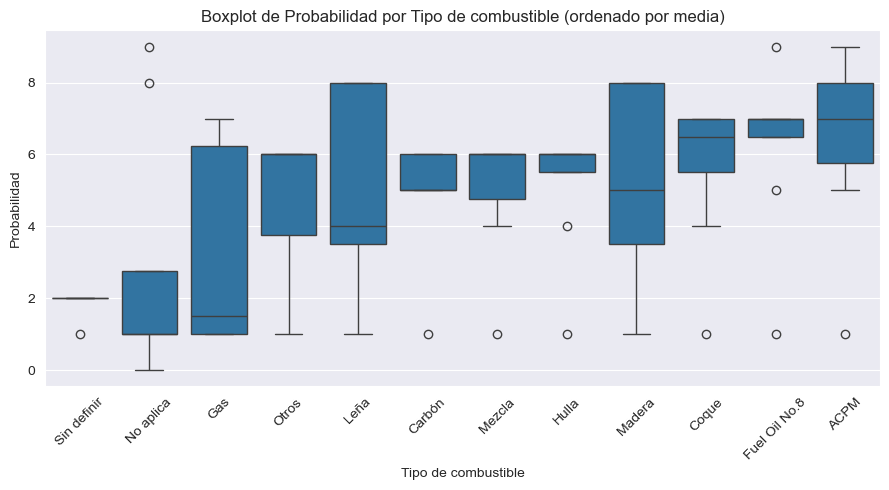

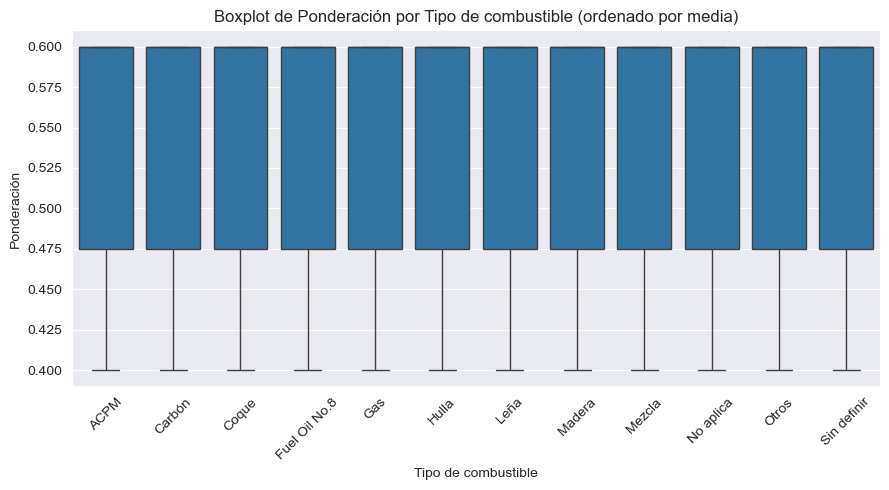

In [13]:
for col in numeric_attributes:
    # Calcular el orden de las categorías por la media de cada Variable
    order = (
        df.groupby("Tipo de combustible")[col]
        .mean()
        .sort_values(ascending=True)  # o ascending=True si quieres de menor a mayor
        .index
    )

    plt.figure(figsize=(9, 5))
    ax = sns.boxplot(data=df, x="Tipo de combustible", y=col, order=order)
    ax.set_title(f"Boxplot de {col} por Tipo de combustible (ordenado por media)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Histogramas para visualizar la distribución de cada columna

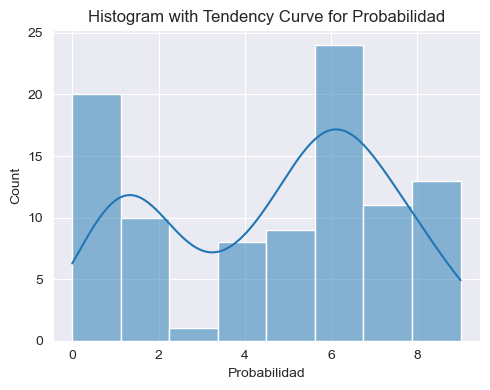

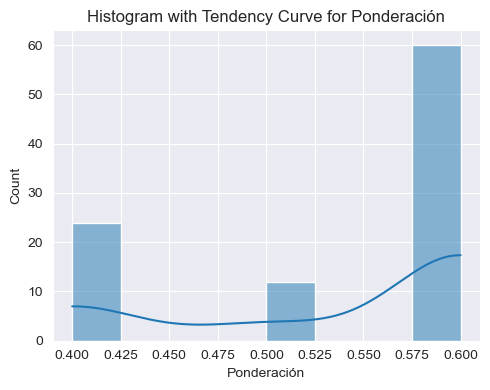

In [14]:
for col in df[numeric_attributes]:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram with Tendency Curve for {col}")
    plt.tight_layout()
    plt.show()

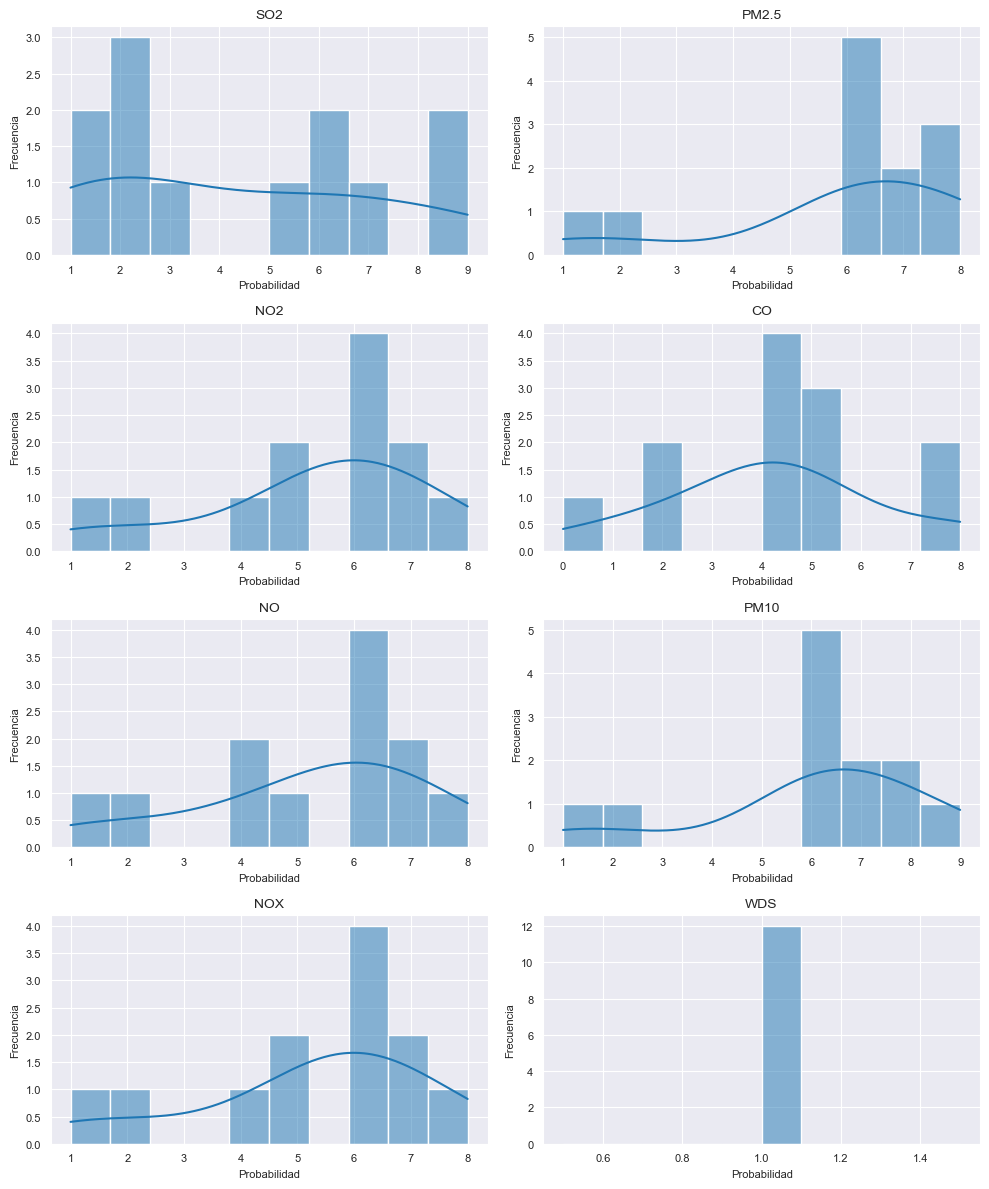

In [15]:
variables_unicas = df['Variable'].unique()
n_vars = len(variables_unicas)

# Calcular grid de subplots con 2 columnas
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
axes = axes.flatten()

for idx, variable in enumerate(variables_unicas):
    datos_variable = df[df['Variable'] == variable]['Probabilidad']
    sns.histplot(datos_variable, kde=True, bins=10, ax=axes[idx])
    axes[idx].set_title(f"{variable}", fontsize=10)
    axes[idx].set_xlabel("Probabilidad", fontsize=8)
    axes[idx].set_ylabel("Frecuencia", fontsize=8)
    axes[idx].tick_params(labelsize=8)

# Ocultar subplots vacíos
for idx in range(len(variables_unicas), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

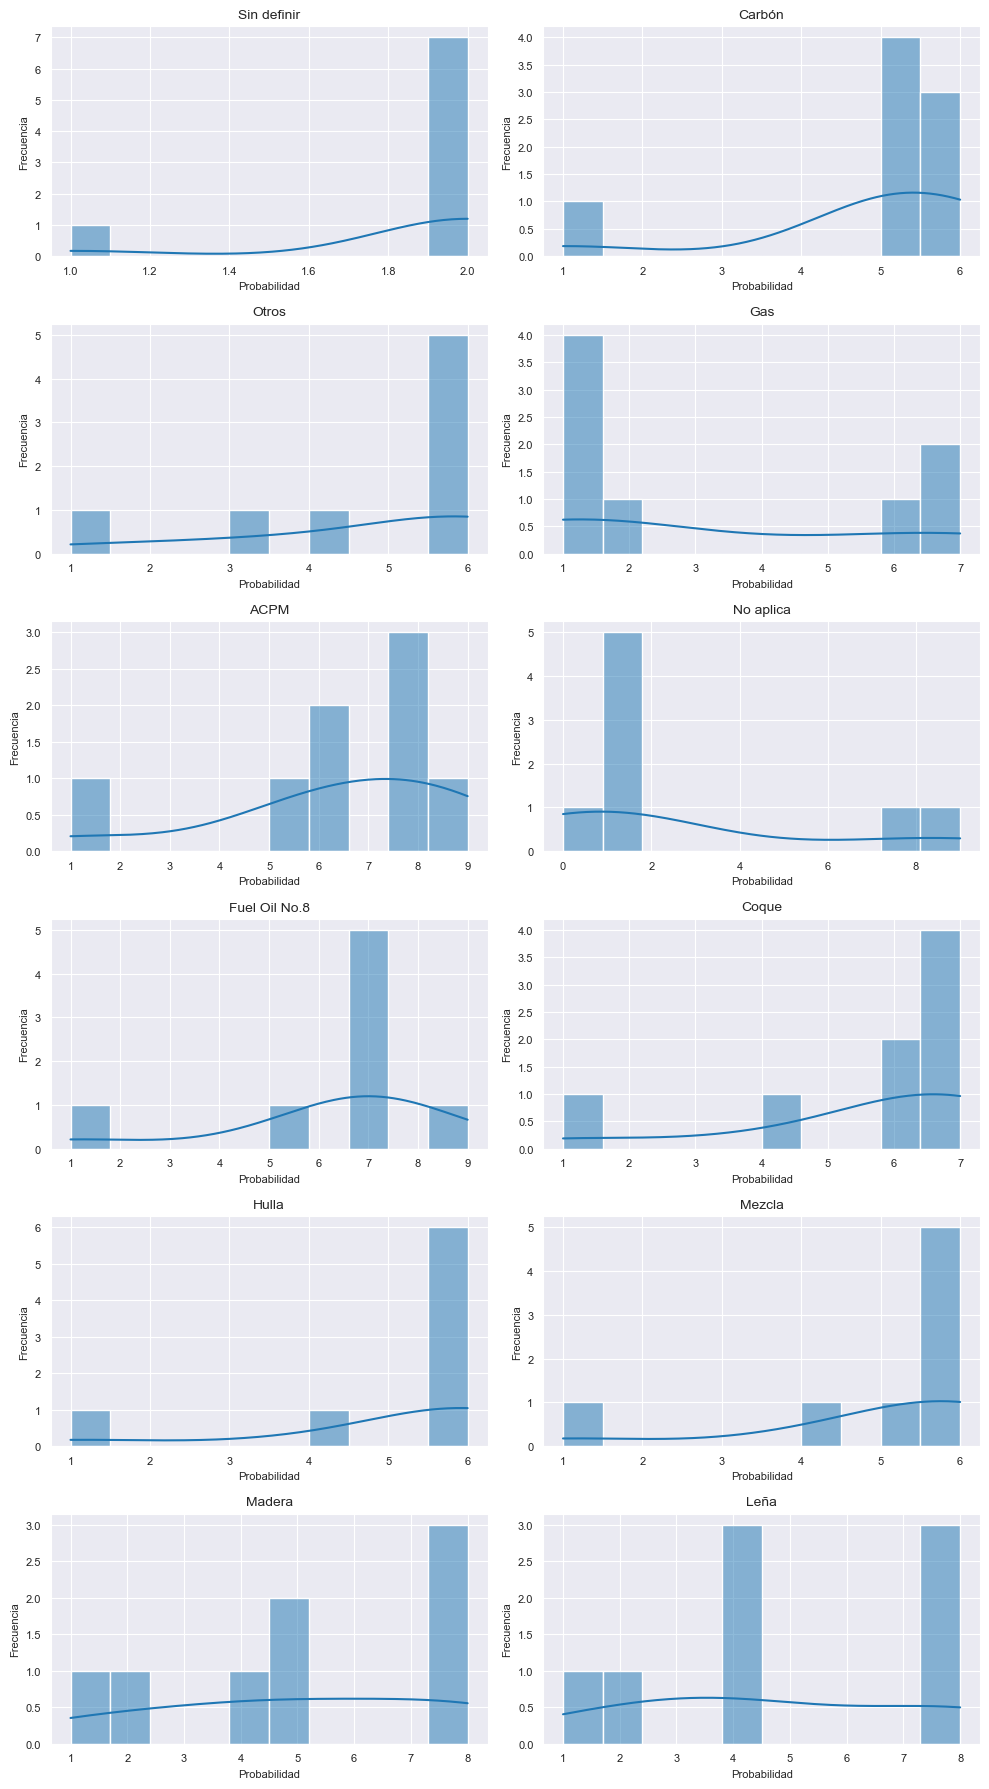

In [16]:
variables_unicas = df['Tipo de combustible'].unique()
n_vars = len(variables_unicas)

# Calcular grid de subplots con 2 columnas
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
axes = axes.flatten()

for idx, variable in enumerate(variables_unicas):
    datos_variable = df[df['Tipo de combustible'] == variable]['Probabilidad']
    sns.histplot(datos_variable, kde=True, bins=10, ax=axes[idx])
    axes[idx].set_title(f"{variable}", fontsize=10)
    axes[idx].set_xlabel("Probabilidad", fontsize=8)
    axes[idx].set_ylabel("Frecuencia", fontsize=8)
    axes[idx].tick_params(labelsize=8)

# Ocultar subplots vacíos
for idx in range(len(variables_unicas), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 4.  Análisis adicionales

Se puede efectuar un Pandas Profiling para encontrar más información

En especial, son de gran interés las correlaciones y las interacciones entre variables

In [17]:
reporte = ProfileReport(df)
reporte.to_file("archivos_generados/Reporte perfilamiento - Dataset 4.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 171.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**Hallazgos:**

Características de las variables:

- Probabilidad tiene 24 (13.3%) ceros

Correlaciones:

- La correlación positiva entre la Variable y la Probabilidad es moderada (0.415)
- La correlación positiva entre el Tipo de combustible y la Probabilidad es baja (0.27)